In [1]:
import pandas as pd 
import numpy as np 
import os
import requests
from PIL import Image
from io import BytesIO
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm import tqdm
import io
import random 

import torch
import torch.nn as nn
import torch.nn.functional as F 
import torch.optim as optim 

import torchvision
from torchvision import transforms
from torchvision import models
import time 
from torch.utils.data import DataLoader, random_split



# Data Collection

In [2]:
phylum_complete_list = [
    'Chordata', 'Arthropoda', 'Mollusca', 'Annelida',
    'Echinodermata', 'Cnidaria', 'Porifera', 'Nematoda', 'Platyhelminthes'
]

In [3]:
'''
+=========================================================+ 
+USE THE CSVS SHARED IN THE GOOGLE DRIVE FOR THE PROJECT+
+=========================================================+
'''

# BASE_PATH = 'animal_phylum_data/'
# MAX_PER_CLASS = 500
# REQUIRED_COLS = ['id', 'url', 'image_url', 'taxon_phylum_name']

# dfs = []
# skipped = []

# for phylum in phylum_complete_list:
#     file_path = os.path.join(BASE_PATH, f"{phylum}.csv")
    
#     try:
#         df = pd.read_csv(file_path, usecols=REQUIRED_COLS)
#         df = df.dropna(subset=['image_url'])
#         df = df.sample(n=min(len(df), MAX_PER_CLASS), random_state=42)
#         dfs.append(df)
#         print(f"✓ {phylum}: {len(df)} rows")
    
#     except FileNotFoundError:
#         print(f"✗ {phylum}: file not found — skipping")
#         skipped.append(phylum)
#     except ValueError as e:
#         print(f"✗ {phylum}: missing columns — {e}")
#         skipped.append(phylum)

# phylum_df = pd.concat(dfs, ignore_index=True)

# # Assertions
# assert len(skipped) == 0, f"Missing phyla: {skipped}"
# assert phylum_df.shape[0] <= MAX_PER_CLASS * len(phylum_complete_list)
# assert phylum_df['image_url'].notna().all(), "Null image URLs slipped through"

# # Summary
# print("\nDone")
# print(phylum_df.groupby('taxon_phylum_name').size().to_string())
# print(f"\nTotal: {phylum_df.shape[0]} rows")

'\n+=========================================================+ \n+USE THE CSVS SHARED IN THE GOOGLE DRIVE FOR THE PROJECT+\n+=========================================================+\n'

In [4]:
'''
+=========================================================+ 
+USE THE IMAGES SHARED IN THE GOOGLE DRIVE FOR THE PROJECT+
+ONLY RUN THIS CELL IF YOU WANNA DOWNLOAD DIRECTLY+
+=========================================================+
'''

# SAVE_DIR = "Data/WildScan_Data/animal_phylum_data/all_images"
# MAX_WORKERS = 16
# TIMEOUT = 10

# os.makedirs(SAVE_DIR, exist_ok=True)

# failed = []
# results = []  # track successes

# def download_image(row):
#     label = row["taxon_phylum_name"]
#     url = row["image_url"]
#     filename = Path(SAVE_DIR) / label / f"{row['id']}.jpg"

#     if filename.exists():
#         return None, "skipped", str(filename)

#     filename.parent.mkdir(parents=True, exist_ok=True)

#     try:
#         response = requests.get(url, timeout=TIMEOUT)
#         response.raise_for_status()
#         img = Image.open(io.BytesIO(response.content))
#         img.verify()
#         with open(filename, "wb") as f:
#             f.write(response.content)
#         return None, "ok", str(filename)

#     except requests.HTTPError as e:
#         return (row['id'], url, f"HTTP {e.response.status_code}"), "failed", None
#     except Exception as e:
#         return (row['id'], url, str(e)), "failed", None

# rows = [row for _, row in phylum_df.iterrows()]
# counts = {"ok": 0, "skipped": 0, "failed": 0}

# with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
#     futures = {executor.submit(download_image, row): row for row in rows}
    
#     with tqdm(total=len(rows), desc="Downloading") as pbar:
#         for future, row in futures.items():
#             error, status, path = future.result()
#             counts[status] += 1
#             if error:
#                 failed.append(error)
#             if path:
#                 results.append({"id": row["id"], "local_path": path})
#             pbar.update(1)

# # Build final DataFrame
# downloaded_df = phylum_df.merge(
#     pd.DataFrame(results),
#     on="id",
#     how="inner"  # only keep successfully downloaded rows
# )

# print(f"\n✓ Downloaded: {counts['ok']}")
# print(f"→ Skipped (exists): {counts['skipped']}")
# print(f"✗ Failed: {counts['failed']}")
# print(f"\nDataFrame shape: {downloaded_df.shape}")
# print(downloaded_df.head())

# downloaded_df.to_csv('animal_phylum_data/downloaded_df.csv', index=False)

# if failed:
#     failed_df = pd.DataFrame(failed, columns=['id', 'url', 'reason'])
#     failed_df.to_csv("failed_downloads.csv", index=False)

'\n+=========================================================+ \n+USE THE IMAGES SHARED IN THE GOOGLE DRIVE FOR THE PROJECT+\n+ONLY RUN THIS CELL IF YOU WANNA DOWNLOAD DIRECTLY+\n+=========================================================+\n'

# Brief EDA 

In [5]:
#Otherwise, just use this and that should be enough
downloaded_df = pd.read_csv('all_csvs/downloaded_df.csv')
downloaded_df.head()

,id,url,image_url,taxon_phylum_name,local_path
0,145107358,https://www.inaturalist.org/observations/14510...,https://inaturalist-open-data.s3.amazonaws.com...,Chordata,all_images/Chordata/145107358.jpg
1,145093257,https://www.inaturalist.org/observations/14509...,https://inaturalist-open-data.s3.amazonaws.com...,Chordata,all_images/Chordata/145093257.jpg
2,161625306,https://www.inaturalist.org/observations/16162...,https://inaturalist-open-data.s3.amazonaws.com...,Chordata,all_images/Chordata/161625306.jpg
3,145204703,https://www.inaturalist.org/observations/14520...,https://inaturalist-open-data.s3.amazonaws.com...,Chordata,all_images/Chordata/145204703.jpg
4,146970747,https://www.inaturalist.org/observations/14697...,https://inaturalist-open-data.s3.amazonaws.com...,Chordata,all_images/Chordata/146970747.jpg


In [6]:
downloaded_df['taxon_phylum_name'].describe()

count         4486
unique           9
top       Cnidaria
freq           500
Name: taxon_phylum_name, dtype: object

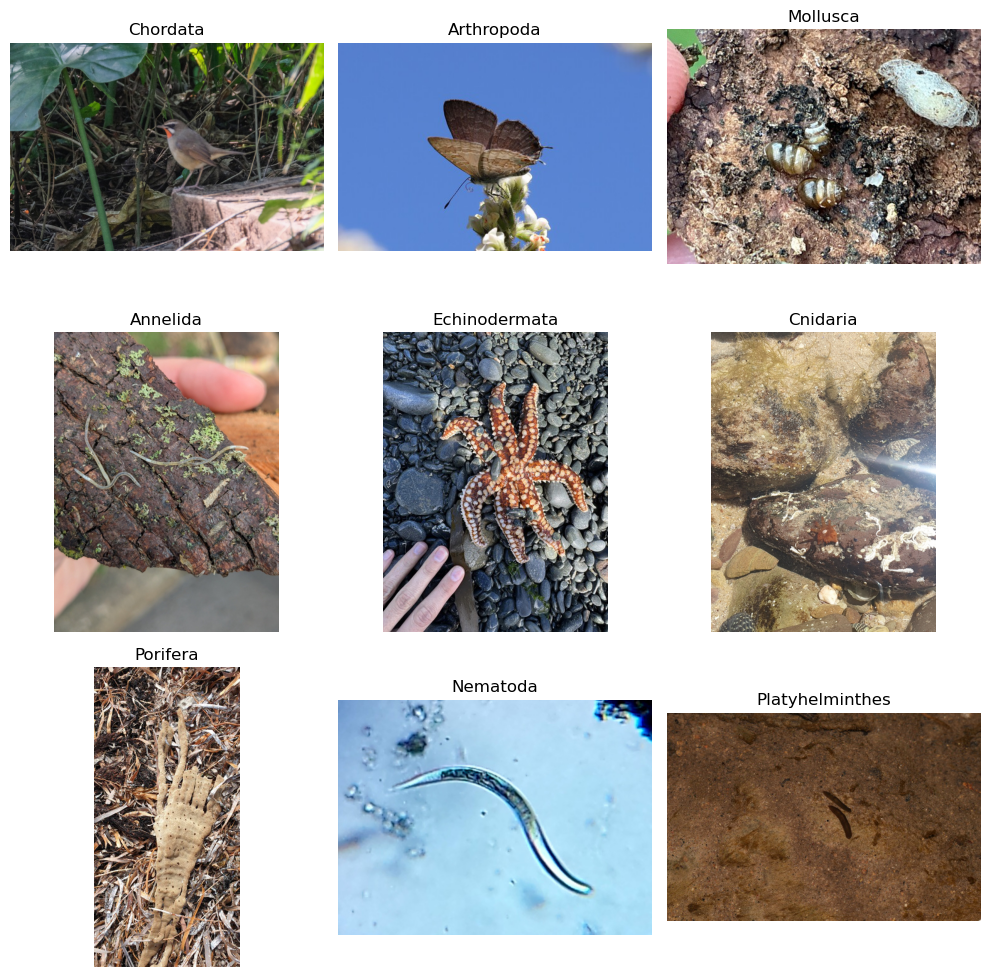

In [7]:
#Showing just one image as an example 
import matplotlib.pyplot as plt
from PIL import Image

fig, axes = plt.subplots(3, 3, figsize=(10, 10))

for ax, phylum in zip(axes.flatten(), phylum_complete_list):
    sample = downloaded_df[downloaded_df['taxon_phylum_name'] == phylum].iloc[0]
    img = Image.open(sample['local_path'])
    ax.imshow(img)
    ax.set_title(phylum)
    ax.axis('off')

plt.tight_layout()
plt.show()

In [8]:
downloaded_df.describe()

,id
count,4.486000e+03
mean,2.702871e+08
std,1.069469e+08
min,2.739800e+04
25%,1.575840e+08
50%,3.465477e+08
75%,3.477038e+08
max,3.557049e+08


In [9]:
#Images that are considered "blurry", may keep these since they are needed for the model to distinguish between phylums!
import cv2
def blurriness(path):
    img = cv2.imread(path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return cv2.Laplacian(gray, cv2.CV_64F).var()

downloaded_df['blur_score'] = downloaded_df['local_path'].apply(blurriness)
downloaded_df[downloaded_df['blur_score'] < 50].shape  

(153, 6)

In [10]:
downloaded_df = downloaded_df[downloaded_df['blur_score'] > 50]
print(downloaded_df.shape)

(4333, 6)


In [11]:
downloaded_df['file_exists'] = downloaded_df['local_path'].apply(os.path.exists)

print(downloaded_df['file_exists'].value_counts())
print(f"\nMissing: {(~downloaded_df['file_exists']).sum()}")

file_exists
True    4333
Name: count, dtype: int64

Missing: 0


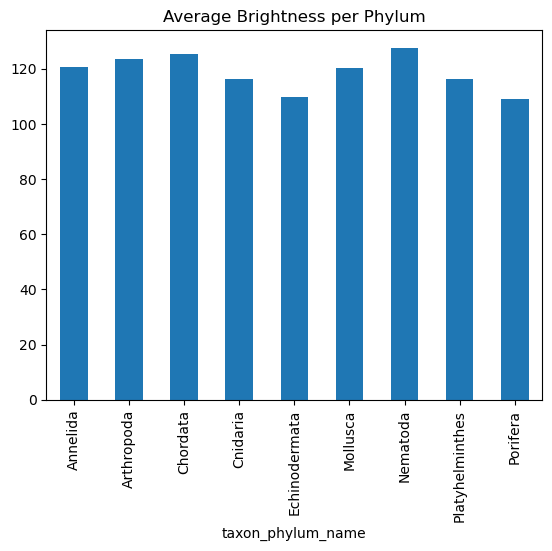

In [12]:
def avg_brightness(path):
    img = Image.open(path).convert("RGB")
    arr = np.array(img)
    return arr.mean()

downloaded_df['brightness'] = downloaded_df['local_path'].apply(avg_brightness)
downloaded_df.groupby('taxon_phylum_name')['brightness'].mean().plot(kind='bar')
plt.title('Average Brightness per Phylum')
plt.show()


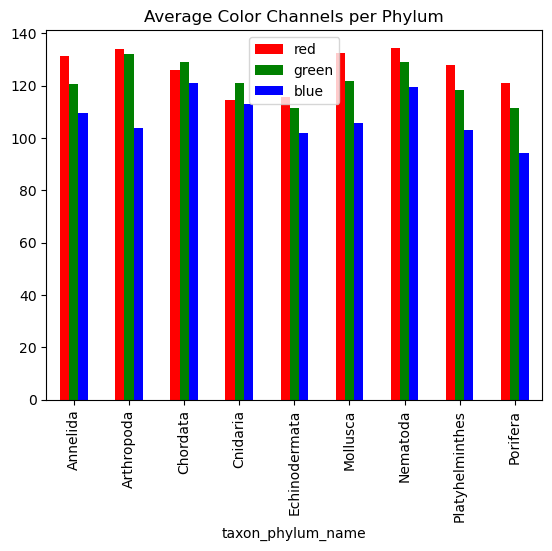

In [13]:
def avg_channels(path):
    img = Image.open(path).convert("RGB")
    arr = np.array(img)
    return pd.Series({'red': arr[:,:,0].mean(), 
                      'green': arr[:,:,1].mean(), 
                      'blue': arr[:,:,2].mean()})

downloaded_df[['red','green','blue']] = downloaded_df['local_path'].apply(avg_channels)

downloaded_df.groupby('taxon_phylum_name')[['red','green','blue']].mean().plot(kind='bar', color=['red', 'green', 'blue'])
plt.title('Average Color Channels per Phylum')
plt.show()

# CNN Training

In [14]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

In [15]:
#Reminder:
phylum_complete_list = [
    'Chordata', 'Arthropoda', 'Mollusca', 'Annelida',
    'Echinodermata', 'Cnidaria', 'Porifera', 'Nematoda', 'Platyhelminthes'
]


In [16]:
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
from PIL import Image

PHYLUM_TO_IDX = {p: i for i, p in enumerate(phylum_complete_list)}

class PhylumDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row['local_path']).convert("RGB")
        label = PHYLUM_TO_IDX[row['taxon_phylum_name']]
        if self.transform:
            image = self.transform(image)
        return image, label

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

dataset = PhylumDataset(downloaded_df, transform=transform)

train_size = int(0.70 * len(dataset))
val_size   = int(0.15 * len(dataset))
test_size  = len(dataset) - train_size - val_size

train_set, val_set, test_set = random_split(dataset, [train_size, val_size, test_size])

train_loader = DataLoader(train_set, batch_size=32, shuffle=True,  num_workers=4)
val_loader   = DataLoader(val_set,   batch_size=32, shuffle=False, num_workers=4)
test_loader  = DataLoader(test_set,  batch_size=32, shuffle=False, num_workers=4)

In [17]:
from torch.utils.data import Dataset

class PhylumDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row['local_path']).convert("RGB")
        label = PHYLUM_TO_IDX[row['taxon_phylum_name']]
        if self.transform:
            image = self.transform(image)
        return image, label

print(PhylumDataset)

<class '__main__.PhylumDataset'>


In [18]:
dataset = PhylumDataset(downloaded_df, transform=transform)
print(len(dataset))

4333


In [19]:
train_size = int(0.70 * len(dataset))
val_size   = int(0.15 * len(dataset))
test_size  = len(dataset) - train_size - val_size

train_set, val_set, test_set = random_split(dataset, [train_size, val_size, test_size])

train_loader = DataLoader(train_set, batch_size=64, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_set,   batch_size=64, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_set,  batch_size=64, shuffle=False, num_workers=0)

print(f"Train: {len(train_set)} | Val: {len(val_set)} | Test: {len(test_set)}")

Train: 3033 | Val: 649 | Test: 651


In [20]:
import torch
import torch.nn as nn
from torchvision import models, transforms

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.mps.manual_seed(SEED)

# Better transforms with augmentation for training
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Apply different transforms to train and val
train_set.dataset.transform = train_transform
val_set.dataset.transform   = val_transform

# Load pretrained ResNet with dropout + better head
model = models.resnet50(pretrained=True)

# Freeze all layers
for param in model.parameters():
    param.requires_grad = False

# Unfreeze layer4
for param in model.layer4.parameters():
    param.requires_grad = True

# Better classification head with dropout
model.fc = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(model.fc.in_features, 256),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(256, 9)
)

device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
model = model.to(device)

optimizer = torch.optim.Adam([
    {'params': model.layer4.parameters(), 'lr': 1e-5},
    {'params': model.fc.parameters(),     'lr': 1e-4}
])
criterion = nn.CrossEntropyLoss()

# Learning rate scheduler — reduces LR when val loss plateaus
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=3, factor=0.5
)

# Early stopping
best_val_loss = float('inf')
patience      = 5
patience_counter = 0

for epoch in range(20):
    # Training
    model.train()
    train_loss, correct = 0, 0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        correct += (outputs.argmax(1) == labels).sum().item()

    # Validation
    model.eval()
    val_loss, val_correct = 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            val_loss += criterion(outputs, labels).item()
            val_correct += (outputs.argmax(1) == labels).sum().item()

    avg_val_loss = val_loss / len(val_loader)
    scheduler.step(avg_val_loss)

    print(f"Epoch {epoch+1}")
    print(f"  Train Loss: {train_loss/len(train_loader):.3f} | Train Acc: {correct/len(train_set):.2%}")
    print(f"  Val Loss:   {avg_val_loss:.3f}           | Val Acc:   {val_correct/len(val_set):.2%}")


/opt/anaconda3/envs/happiness_env/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/anaconda3/envs/happiness_env/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1
  Train Loss: 2.055 | Train Acc: 28.85%
  Val Loss:   1.754           | Val Acc:   54.08%
Epoch 2
  Train Loss: 1.586 | Train Acc: 49.75%
  Val Loss:   1.276           | Val Acc:   60.09%
Epoch 3
  Train Loss: 1.207 | Train Acc: 62.02%
  Val Loss:   1.087           | Val Acc:   65.18%
Epoch 4
  Train Loss: 0.997 | Train Acc: 67.10%
  Val Loss:   1.004           | Val Acc:   66.87%
Epoch 5
  Train Loss: 0.856 | Train Acc: 72.21%
  Val Loss:   1.004           | Val Acc:   67.33%
Epoch 6
  Train Loss: 0.723 | Train Acc: 76.49%
  Val Loss:   0.928           | Val Acc:   68.57%
Epoch 7
  Train Loss: 0.608 | Train Acc: 79.92%
  Val Loss:   0.920           | Val Acc:   69.95%
Epoch 8
  Train Loss: 0.511 | Train Acc: 83.71%
  Val Loss:   0.942           | Val Acc:   69.95%
Epoch 9
  Train Loss: 0.401 | Train Acc: 87.44%
  Val Loss:   0.928           | Val Acc:   70.11%
Epoch 10
  Train Loss: 0.313 | Train Acc: 91.10%
  Val Loss:   0.972           | Val Acc:   69.95%
Epoch 11
  Train Lo